# 18 — Demand Forecasting for Dynamic Pricing (statsmodels)

Forecast **demand theo tháng** bằng **statsmodels** trên `hotel_bookings_v5.csv`, theo Workflow 4 (Time Series Forecasting) của skill `statsmodels`:

1. Plot series + seasonality  
2. Stationarity tests (**ADF**, **KPSS**)  
3. ACF / PACF để gợi ý bậc  
4. Fit **SARIMAX** (chọn order bằng AIC/BIC) + **Holt–Winters**  
5. Residual diagnostics (`plot_diagnostics`, Ljung–Box)  
6. Forecast có **prediction intervals**  
7. Holdout accuracy vs **Seasonal Naive** baseline  

**Phạm vi:** stay demand `is_canceled = 0` · primary target = monthly bookings · chuỗi ~26 tháng (2015-07 → 2017-08).

In [1]:
import os
import warnings
from itertools import product
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss

%matplotlib inline
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

NOTEBOOK_DIR = Path(os.environ.get("VSCODE_NOTEBOOK_DIR", Path.cwd()))
ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR.parent / "data").is_dir() else NOTEBOOK_DIR
DATA_PATH = ROOT / "data" / "hotel_bookings_v5.csv"
FIG_DIR = ROOT / "reports" / "figures" / "18"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MONTH_MAP = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12,
}
SEASON = 12
HOLDOUT = 6  # last 6 months for out-of-sample eval

print(f"statsmodels {sm.__version__}")
print(f"ROOT: {ROOT}")
print(f"DATA: {DATA_PATH}")
print(f"FIG_DIR: {FIG_DIR}")

statsmodels 0.14.6
ROOT: C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python
DATA: C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\data\hotel_bookings_v5.csv
FIG_DIR: C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\reports\figures\18


In [2]:
def fmt_int(n) -> str:
    return f"{int(round(n)):,}".replace(",", ".")


def fmt_pct(x: float, d: int = 1) -> str:
    return f"{x * 100:.{d}f}%".replace(".", ",")


def savefig(name: str) -> Path:
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=140, bbox_inches="tight")
    print(f"Saved: {path.relative_to(ROOT)}")
    return path


def mape(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])))


def mae(y_true, y_pred) -> float:
    return float(np.mean(np.abs(np.asarray(y_true, float) - np.asarray(y_pred, float))))


def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(np.mean((np.asarray(y_true, float) - np.asarray(y_pred, float)) ** 2)))


def load_monthly_demand() -> tuple[pd.Series, pd.DataFrame]:
    df = pd.read_csv(DATA_PATH)
    stay = df[df["is_canceled"] == 0].copy()
    stay["month_num"] = stay["arrival_date_month"].map(MONTH_MAP)
    stay["ym"] = pd.to_datetime(
        dict(year=stay["arrival_date_year"], month=stay["month_num"], day=1)
    )
    if "total_nights" not in stay.columns:
        stay["total_nights"] = (
            stay["stays_in_weekend_nights"] + stay["stays_in_week_nights"]
        ).clip(lower=0)

    overall = (
        stay.groupby("ym", as_index=False)
        .agg(bookings=("hotel", "size"), room_nights=("total_nights", "sum"))
        .sort_values("ym")
        .reset_index(drop=True)
    )
    y = overall.set_index("ym")["bookings"].asfreq("MS").astype(float)
    by_hotel = (
        stay.groupby(["hotel", "ym"], as_index=False)
        .agg(bookings=("hotel", "size"))
        .sort_values(["hotel", "ym"])
    )
    return y, by_hotel


y, by_hotel = load_monthly_demand()
print(f"Months: {len(y)} | {y.index.min().date()} → {y.index.max().date()}")
print(f"Total stay bookings: {fmt_int(y.sum())}")
display(y.to_frame("bookings").head(8))

Months: 26 | 2015-07-01 → 2017-08-01
Total stay bookings: 59.527


,bookings
ym,
2015-07-01,1095.0
2015-08-01,1755.0
2015-09-01,2027.0
2015-10-01,2008.0
2015-11-01,1272.0
2015-12-01,1507.0
2016-01-01,1439.0
2016-02-01,2152.0


## 1. Plot series & seasonal decomposition

Saved: reports\figures\18\01_monthly_demand_overall.png


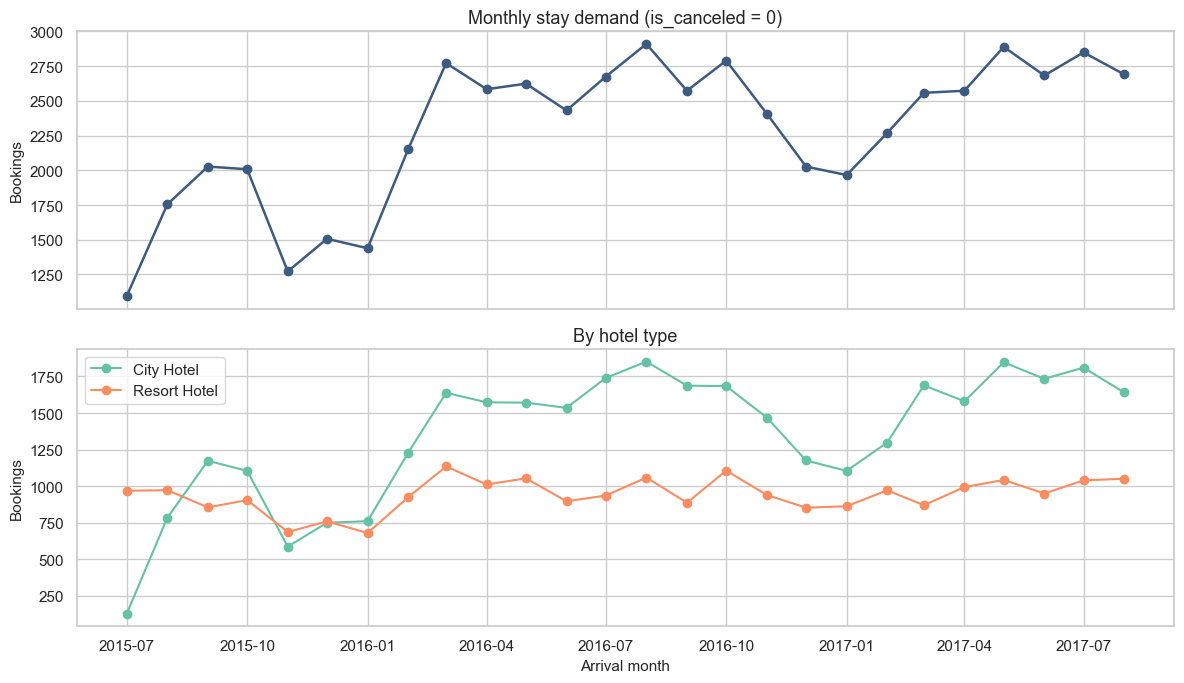

Saved: reports\figures\18\02_seasonal_decompose.png


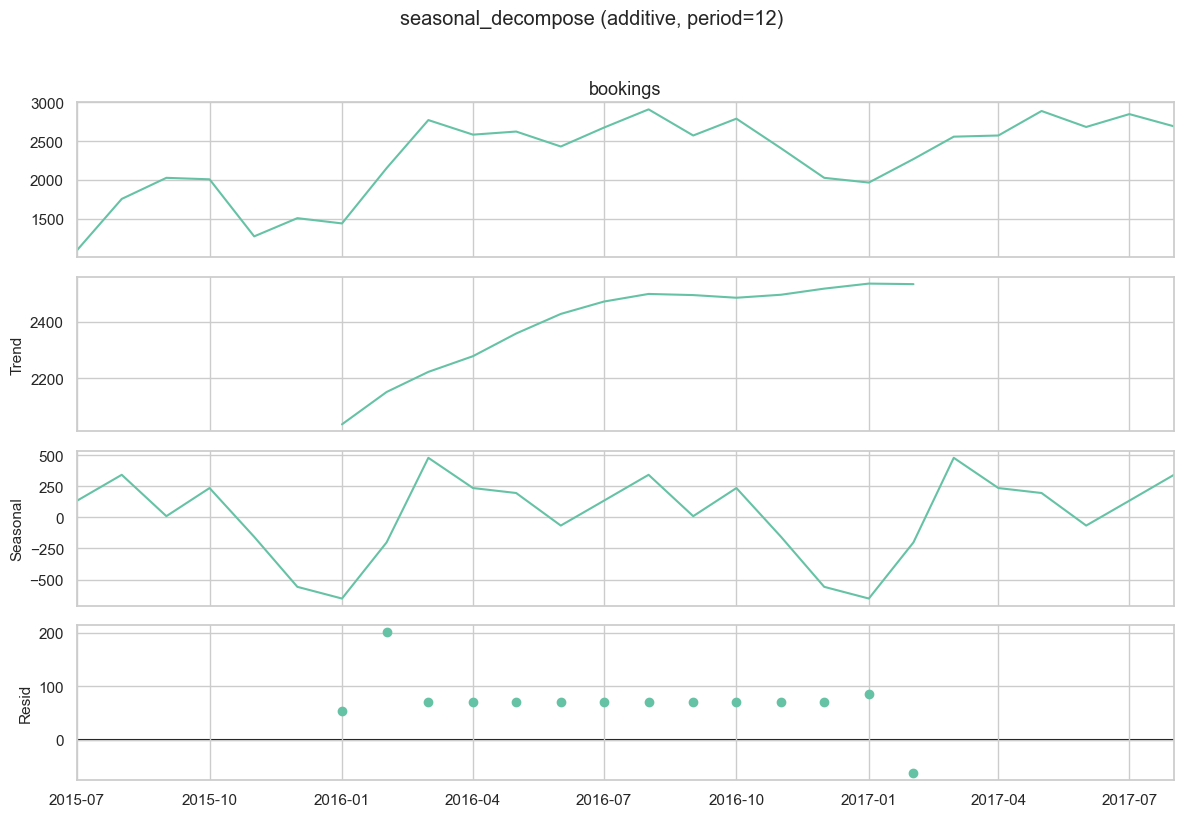

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(y.index, y.values, marker="o", lw=1.8, color="#3d5a80")
axes[0].set_ylabel("Bookings")
axes[0].set_title("Monthly stay demand (is_canceled = 0)")

for hotel, g in by_hotel.groupby("hotel"):
    g = g.set_index("ym").sort_index()
    axes[1].plot(g.index, g["bookings"], marker="o", label=hotel, lw=1.5)
axes[1].set_ylabel("Bookings")
axes[1].set_title("By hotel type")
axes[1].legend()
axes[1].set_xlabel("Arrival month")
savefig("01_monthly_demand_overall.png")
plt.show()

# Classical seasonal decompose (additive) — needs >= 2 seasons
decomp = seasonal_decompose(y, model="additive", period=SEASON)
fig = decomp.plot()
fig.set_size_inches(12, 8)
fig.suptitle("seasonal_decompose (additive, period=12)", y=1.02)
savefig("02_seasonal_decompose.png")
plt.show()

## 2. Stationarity — ADF & KPSS

- **ADF** H₀: unit root (non-stationary) → reject nếu p < 0.05  
- **KPSS** H₀: stationary → reject nếu p < 0.05  
- Kết hợp hai test để chọn bậc differencing `d` / `D`

In [4]:
def stationarity_report(series: pd.Series, name: str) -> dict:
    series = series.dropna().astype(float)
    adf_stat, adf_p, *_ = adfuller(series, autolag="AIC")
    try:
        kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
    except Exception as e:
        kpss_stat, kpss_p = np.nan, np.nan
        print(f"KPSS warning ({name}): {e}")
    row = {
        "series": name,
        "n": len(series),
        "adf_stat": adf_stat,
        "adf_pvalue": adf_p,
        "adf_stationary_5pct": adf_p < 0.05,
        "kpss_stat": kpss_stat,
        "kpss_pvalue": kpss_p,
        "kpss_stationary_5pct": kpss_p >= 0.05 if pd.notna(kpss_p) else np.nan,
    }
    return row


candidates = {
    "level": y,
    "diff1": y.diff().dropna(),
    "seasonal_diff12": y.diff(SEASON).dropna(),
    "diff1_seasonal12": y.diff().diff(SEASON).dropna(),
}
stat_rows = [stationarity_report(s, name) for name, s in candidates.items()]
stat_df = pd.DataFrame(stat_rows)
display(stat_df.round(4))
stat_df.to_csv(FIG_DIR / "stationarity_tests.csv", index=False)

# Decision rule (skill): ADF stationary + KPSS stationary.
# Prefer less aggressive differencing when multiple candidates pass (short n≈26).
def pick_diff_orders(stat_df: pd.DataFrame) -> tuple[int, int]:
    for name, d, D in [
        ("diff1", 1, 0),
        ("seasonal_diff12", 0, 1),
        ("diff1_seasonal12", 1, 1),
        ("level", 0, 0),
    ]:
        row = stat_df.loc[stat_df["series"] == name].iloc[0]
        adf_ok = bool(row["adf_stationary_5pct"])
        kpss_ok = bool(row["kpss_stationary_5pct"]) if pd.notna(row["kpss_stationary_5pct"]) else False
        if adf_ok and kpss_ok:
            return d, D
    # Monthly hotel demand fallback: seasonal difference
    return 0, 1


d_order, D_order = pick_diff_orders(stat_df)
print(f"Selected differencing: d={d_order}, D={D_order} (s={SEASON})")
# Keep seasonal SMA term available even if D=0 (common airline-style monthly specs)
force_seasonal_Q = D_order == 0  # allow (P,0,Q,12) search when only regular diff is needed
print(f"Also search seasonal AR/MA with D fixed: {D_order} (force seasonal MA candidates if D=0: {force_seasonal_Q})")

,series,n,adf_stat,adf_pvalue,adf_stationary_5pct,kpss_stat,kpss_pvalue,kpss_stationary_5pct
0,level,26,-2.6084,0.0913,False,0.4915,0.0436,False
1,diff1,25,-4.8232,0.0000,True,0.1135,0.1000,True
2,seasonal_diff12,14,-35.5313,0.0000,True,0.6545,0.0177,False
3,diff1_seasonal12,13,-4.0990,0.0010,True,0.1053,0.1000,True


Selected differencing: d=1, D=0 (s=12)
Also search seasonal AR/MA with D fixed: 0 (force seasonal MA candidates if D=0: True)


## 3. ACF / PACF (sau differencing đã chọn)

Saved: reports\figures\18\03_acf_pacf.png


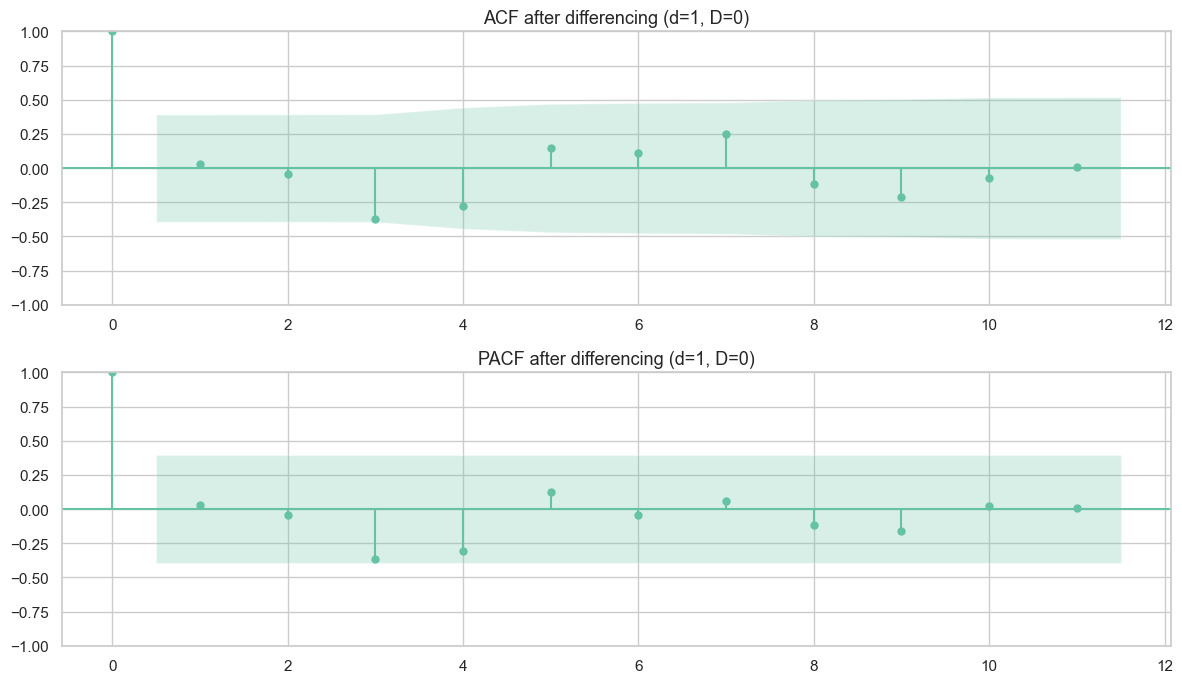

Rules of thumb: PACF cutoff → p; ACF cutoff → q; seasonal spikes at 12 → P/Q.
Using ACF/PACF + AIC grid with fixed d=1, D=0.


In [5]:
if D_order == 1 and d_order == 1:
    y_acf = y.diff().diff(SEASON).dropna()
elif D_order == 1:
    y_acf = y.diff(SEASON).dropna()
elif d_order == 1:
    y_acf = y.diff().dropna()
else:
    y_acf = y.copy()

max_lags = min(18, max(6, len(y_acf) // 2 - 1))
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
plot_acf(y_acf, lags=max_lags, ax=axes[0])
axes[0].set_title(f"ACF after differencing (d={d_order}, D={D_order})")
plot_pacf(y_acf, lags=max_lags, ax=axes[1], method="ywm")
axes[1].set_title(f"PACF after differencing (d={d_order}, D={D_order})")
savefig("03_acf_pacf.png")
plt.show()

print("Rules of thumb: PACF cutoff → p; ACF cutoff → q; seasonal spikes at 12 → P/Q.")
print(f"Using ACF/PACF + AIC grid with fixed d={d_order}, D={D_order}.")

## 4. Model selection — SARIMAX grid (AIC/BIC) + Holt–Winters

Grid nhỏ vì n≈26: `p,q ∈ {0,1,2}`, `P,Q ∈ {0,1}`, `d,D` cố định từ bước stationarity.
Baseline **Seasonal Naive** giữ để so sánh holdout (không phải model statsmodels, nhưng bắt buộc cho pricing validation).

In [6]:
train = y.iloc[:-HOLDOUT]
test = y.iloc[-HOLDOUT:]
print(f"Train: {train.index.min().date()} → {train.index.max().date()} (n={len(train)})")
print(f"Test : {test.index.min().date()} → {test.index.max().date()} (n={len(test)})")


def fit_sarimax(series, order, seasonal_order):
    model = SARIMAX(
        series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    return model.fit(disp=False)


p_vals = range(0, 3)
q_vals = range(0, 3)
P_vals = range(0, 2)
Q_vals = range(0, 2)

grid_rows = []
for p, q, P, Q in product(p_vals, q_vals, P_vals, Q_vals):
    order = (p, d_order, q)
    seasonal_order = (P, D_order, Q, SEASON)
    # skip white-noise / null
    if (p, d_order, q) == (0, 0, 0) and P == 0 and Q == 0:
        continue
    try:
        res = fit_sarimax(train, order, seasonal_order)
        aic_v, bic_v, llf_v = float(res.aic), float(res.bic), float(res.llf)
        # discard degenerate fits (common when seasonal burn consumes short samples)
        if not np.isfinite(aic_v) or not np.isfinite(llf_v):
            continue
        grid_rows.append(
            {
                "order": str(order),
                "seasonal_order": str(seasonal_order),
                "p": p, "d": d_order, "q": q,
                "P": P, "D": D_order, "Q": Q,
                "aic": aic_v,
                "bic": bic_v,
                "llf": llf_v,
            }
        )
    except Exception:
        continue

grid = pd.DataFrame(grid_rows).sort_values(["aic", "bic"]).reset_index(drop=True)
print(f"Fitted {len(grid)} usable SARIMAX candidates on train")
display(grid.head(10).round(2))
grid.to_csv(FIG_DIR / "sarimax_aic_grid.csv", index=False)

if len(grid) == 0:
    raise RuntimeError("No SARIMAX candidate fitted — relax grid or holdout.")

best = grid.iloc[0]
best_order = (int(best["p"]), int(best["d"]), int(best["q"]))
best_seasonal = (int(best["P"]), int(best["D"]), int(best["Q"]), SEASON)
print(
    f"Best SARIMAX by AIC: {best_order} x {best_seasonal} | "
    f"AIC={best['aic']:.2f} BIC={best['bic']:.2f} LLF={best['llf']:.2f}"
)

sarimax_train = fit_sarimax(train, best_order, best_seasonal)
print(sarimax_train.summary())

Train: 2015-07-01 → 2017-02-01 (n=20)
Test : 2017-03-01 → 2017-08-01 (n=6)


Fitted 36 usable SARIMAX candidates on train


,order,seasonal_order,p,d,q,P,D,Q,aic,bic,llf
0,"(0, 1, 2)","(1, 0, 1, 12)",0,1,2,1,0,1,62.81,59.74,-26.41
1,"(1, 1, 2)","(1, 0, 1, 12)",1,1,2,1,0,1,63.16,59.48,-25.58
2,"(0, 1, 2)","(0, 0, 1, 12)",0,1,2,0,0,1,63.45,61.00,-27.73
3,"(2, 1, 2)","(1, 0, 1, 12)",2,1,2,1,0,1,65.05,60.76,-25.53
4,"(2, 1, 2)","(0, 0, 1, 12)",2,1,2,0,0,1,65.12,61.43,-26.56
5,"(1, 1, 2)","(0, 0, 1, 12)",1,1,2,0,0,1,65.16,62.09,-27.58
6,"(2, 1, 2)","(1, 0, 0, 12)",2,1,2,1,0,0,75.01,72.67,-31.51
7,"(2, 1, 1)","(1, 0, 0, 12)",2,1,1,1,0,0,76.10,74.15,-33.05
8,"(2, 1, 0)","(1, 0, 0, 12)",2,1,0,1,0,0,76.50,74.94,-34.25
9,"(0, 1, 1)","(0, 0, 1, 12)",0,1,1,0,0,1,76.67,75.49,-35.33


Best SARIMAX by AIC: (0, 1, 2) x (1, 0, 1, 12) | AIC=62.81 BIC=59.74 LLF=-26.41
                                      SARIMAX Results                                       
Dep. Variable:                             bookings   No. Observations:                   20
Model:             SARIMAX(0, 1, 2)x(1, 0, [1], 12)   Log Likelihood                 -26.406
Date:                              Mon, 20 Jul 2026   AIC                             62.812
Time:                                      08:12:03   BIC                             59.744
Sample:                                  07-01-2015   HQIC                            56.079
                                       - 02-01-2017                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          1.8

In [7]:
def fit_holt_winters(series: pd.Series, label: str = "series"):
    # Seasonal HW needs >= 2 full cycles; else Holt trend-only (statsmodels constraint)
    n = len(series)
    if n >= 2 * SEASON:
        model = ExponentialSmoothing(
            series,
            trend="add",
            seasonal="add",
            seasonal_periods=SEASON,
            initialization_method="estimated",
        )
        kind = "holt_winters_seasonal"
    else:
        print(
            f"[{label}] n={n} < {2 * SEASON}: seasonal HW unavailable -> Holt trend-only fallback"
        )
        model = ExponentialSmoothing(
            series,
            trend="add",
            seasonal=None,
            initialization_method="estimated",
        )
        kind = "holt_trend"
    res = model.fit(optimized=True)
    return res, kind


hw_train, hw_train_kind = fit_holt_winters(train, "train")
print(f"Train exponential smoothing kind: {hw_train_kind}")
print(hw_train.summary())

# Optional ETS state-space when enough history
ets_train = None
if len(train) >= 2 * SEASON:
    try:
        from statsmodels.tsa.exponential_smoothing.ets import ETSModel
        ets_train = ETSModel(
            train,
            error="add",
            trend="add",
            seasonal="add",
            seasonal_periods=SEASON,
        ).fit(disp=False)
        print("ETS AIC:", round(ets_train.aic, 2))
    except Exception as e:
        print("ETSModel skipped:", e)
else:
    print("ETS seasonal skipped on train (need >= 2 seasonal cycles).")

[train] n=20 < 24: seasonal HW unavailable -> Holt trend-only fallback
Train exponential smoothing kind: holt_trend
                       ExponentialSmoothing Model Results                       
Dep. Variable:                 bookings   No. Observations:                   20
Model:             ExponentialSmoothing   SSE                        2667945.163
Optimized:                         True   AIC                            244.022
Trend:                         Additive   BIC                            248.005
Seasonal:                          None   AICC                           250.483
Seasonal Periods:                  None   Date:                 Mon, 20 Jul 2026
Box-Cox:                          False   Time:                         08:12:03
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
----------------------------------------------------------------------------

## 5. Residual diagnostics (train fit)

plot_diagnostics skipped: Length of endogenous variable must be larger the the number of lags used in the model and the number of observations burned in the log-likelihood calculation.


Saved: reports\figures\18\04_sarimax_diagnostics.png


<Figure size 1200x800 with 0 Axes>

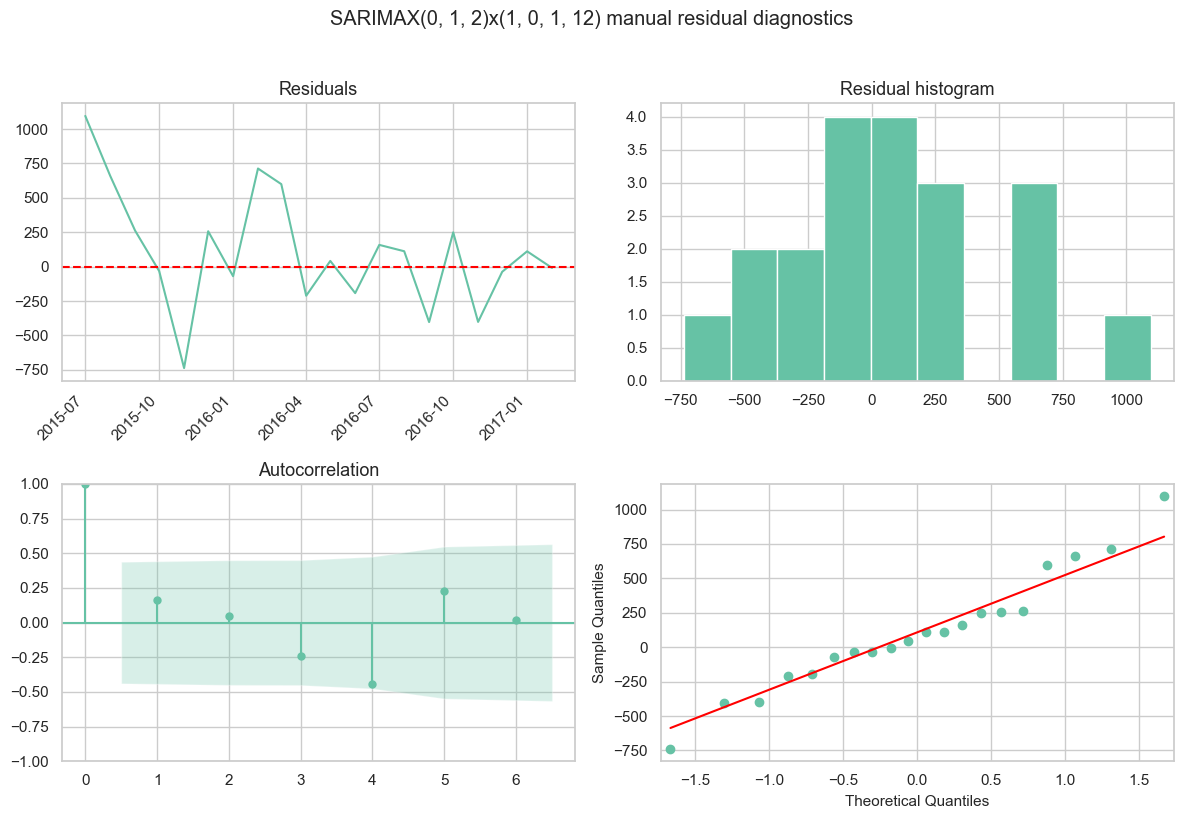

Ljung-Box on SARIMAX residuals:


,lb_stat,lb_pvalue
3,2.213071,0.529378
6,9.010357,0.172996
12,16.145473,0.184664


Ljung-Box on holt_trend residuals:


,lb_stat,lb_pvalue
3,3.381389,0.336474
6,7.006452,0.320251
12,14.294400,0.282305


,model,ljungbox_lag6_pvalue,ljungbox_lag12_pvalue,resid_mean,resid_std
0,SARIMAX,0.1730,0.1847,108.1781,427.5224
1,holt_trend,0.3203,0.2823,-0.0003,374.7241


In [8]:
import matplotlib.dates as mdates
resid = pd.Series(sarimax_train.resid, index=train.index).dropna()
# Short series: plot_diagnostics default lags may exceed usable residuals
diag_lags = max(4, min(8, len(resid) // 3))


def _format_resid_time_axis(ax) -> None:
    # Sparse ticks for small subplot width (avoid overlapping YYYY-MM labels)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=45)
    plt.setp(ax.get_xticklabels(), ha="right")


try:
    fig = sarimax_train.plot_diagnostics(figsize=(12, 8), lags=diag_lags)
    fig.suptitle(f"SARIMAX{best_order}x{best_seasonal} residual diagnostics", y=1.02)
    _format_resid_time_axis(fig.axes[0])
    savefig("04_sarimax_diagnostics.png")
    plt.show()
except ValueError as e:
    print("plot_diagnostics skipped:", e)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes[0, 0].plot(resid.index, resid.values)
    axes[0, 0].axhline(0, color="r", ls="--")
    axes[0, 0].set_title("Residuals")
    _format_resid_time_axis(axes[0, 0])
    axes[0, 1].hist(resid.values, bins=10, edgecolor="white")
    axes[0, 1].set_title("Residual histogram")
    plot_acf(resid, lags=diag_lags, ax=axes[1, 0])
    sm.qqplot(resid, line="s", ax=axes[1, 1])
    fig.suptitle(f"SARIMAX{best_order}x{best_seasonal} manual residual diagnostics", y=1.02)
    savefig("04_sarimax_diagnostics.png")
    plt.show()

lb_lags = [lag for lag in [3, 6, 12] if lag < len(resid)]
lb = acorr_ljungbox(resid, lags=lb_lags, return_df=True)
print("Ljung-Box on SARIMAX residuals:")
display(lb)

hw_resid = pd.Series(train - hw_train.fittedvalues, index=train.index).dropna()
lb_hw_lags = [lag for lag in [3, 6, 12] if lag < len(hw_resid)]
lb_hw = acorr_ljungbox(hw_resid, lags=lb_hw_lags, return_df=True)
print(f"Ljung-Box on {hw_train_kind} residuals:")
display(lb_hw)


def lb_p(df, lag):
    return float(df.loc[lag, "lb_pvalue"]) if lag in df.index else np.nan


diag_summary = pd.DataFrame(
    {
        "model": ["SARIMAX", hw_train_kind],
        "ljungbox_lag6_pvalue": [lb_p(lb, 6), lb_p(lb_hw, 6)],
        "ljungbox_lag12_pvalue": [lb_p(lb, 12), lb_p(lb_hw, 12)],
        "resid_mean": [resid.mean(), hw_resid.mean()],
        "resid_std": [resid.std(), hw_resid.std()],
    }
)
display(diag_summary.round(4))
diag_summary.to_csv(FIG_DIR / "residual_diagnostics.csv", index=False)

## 6. Holdout evaluation + prediction intervals

So sánh trên 6 tháng cuối:
- Seasonal Naive: `ŷ_t = y_{t-12}`
- SARIMAX `get_forecast` → mean + 95% CI
- Holt–Winters `forecast`

In [9]:
def seasonal_naive(history: pd.Series, steps: int) -> np.ndarray:
    out, cur = [], history.astype(float).copy()
    for _ in range(steps):
        pred = float(cur.iloc[-SEASON]) if len(cur) >= SEASON else float(cur.mean())
        out.append(pred)
        cur = pd.concat([cur, pd.Series([pred], index=[cur.index[-1] + pd.offsets.MonthBegin(1)])])
    return np.asarray(out)


# Point forecasts on holdout
fc_naive = seasonal_naive(train, HOLDOUT)
fc_hw = np.asarray(hw_train.forecast(HOLDOUT), dtype=float)
hw_holdout_label = hw_train_kind  # may be holt_trend on short train

sarimax_fc = sarimax_train.get_forecast(steps=HOLDOUT)
fc_sarimax = np.asarray(sarimax_fc.predicted_mean, dtype=float)
ci_sarimax = sarimax_fc.conf_int(alpha=0.05)
ci_sarimax.columns = ["lower_95", "upper_95"]

holdout = pd.DataFrame(
    {
        "ym": test.index,
        "actual": test.values,
        "seasonal_naive": fc_naive,
        hw_holdout_label: fc_hw,
        "sarimax": fc_sarimax,
        "sarimax_lower95": ci_sarimax["lower_95"].values,
        "sarimax_upper95": ci_sarimax["upper_95"].values,
    }
)
# demand can't be negative for reporting
for c in ["seasonal_naive", hw_holdout_label, "sarimax", "sarimax_lower95"]:
    holdout[c] = holdout[c].clip(lower=0)

display(holdout.round(1))

metrics = []
for name in ["seasonal_naive", hw_holdout_label, "sarimax"]:
    metrics.append(
        {
            "model": name,
            "MAE": mae(holdout["actual"], holdout[name]),
            "RMSE": rmse(holdout["actual"], holdout[name]),
            "MAPE": mape(holdout["actual"], holdout[name]),
        }
    )
metrics_df = pd.DataFrame(metrics).sort_values("MAPE").reset_index(drop=True)
display(metrics_df.style.format({"MAE": "{:.1f}", "RMSE": "{:.1f}", "MAPE": "{:.2%}"}))
metrics_df.to_csv(FIG_DIR / "holdout_metrics.csv", index=False)
holdout.to_csv(FIG_DIR / "holdout_forecast_detail.csv", index=False)

best_model = metrics_df.iloc[0]["model"]
print(f"Best holdout model (MAPE): {best_model}")

# Coverage of SARIMAX 95% PI
inside = (
    (holdout["actual"] >= holdout["sarimax_lower95"])
    & (holdout["actual"] <= holdout["sarimax_upper95"])
).mean()
print(f"SARIMAX 95% PI coverage on holdout: {inside:.1%}")

,ym,actual,seasonal_naive,holt_trend,sarimax,sarimax_lower95,sarimax_upper95
0,2017-03-01,2558.0,2772.0,2330.8,2466.7,2168.4,2764.9
1,2017-04-01,2573.0,2584.0,2392.6,2442.6,1614.2,3271.0
2,2017-05-01,2889.0,2624.0,2454.4,2445.0,1156.9,3733.2
3,2017-06-01,2683.0,2431.0,2516.2,2408.8,789.2,4028.3
4,2017-07-01,2849.0,2675.0,2578.0,2446.1,551.9,4340.2
5,2017-08-01,2691.0,2910.0,2639.7,2522.9,399.0,4646.8


,model,MAE,RMSE,MAPE
0,seasonal_naive,189.2,207.3,6.93%
1,holt_trend,221.9,250.7,8.10%
2,sarimax,251.8,285.3,9.10%


Best holdout model (MAPE): seasonal_naive
SARIMAX 95% PI coverage on holdout: 100.0%


Saved: reports\figures\18\05_holdout_forecasts.png


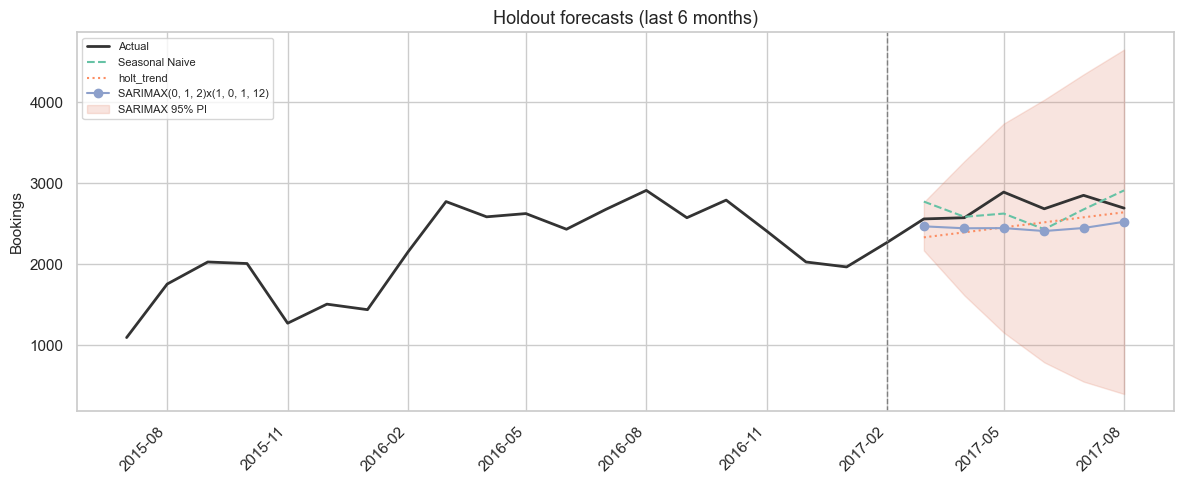

Saved: reports\figures\18\05_holdout_metrics.png


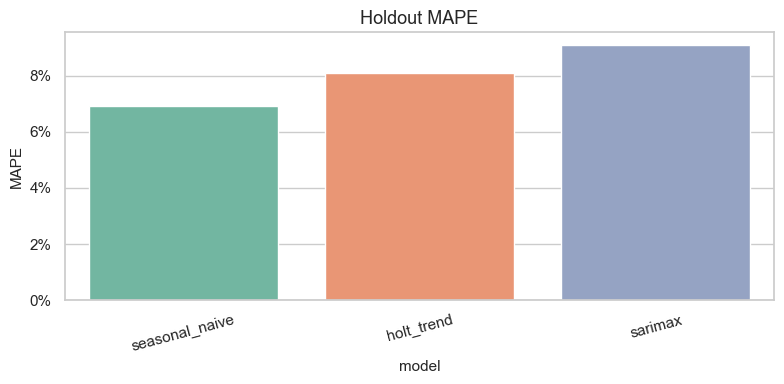

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y.index, y.values, color="#333", lw=2, label="Actual")
ax.plot(holdout["ym"], holdout["seasonal_naive"], ls="--", label="Seasonal Naive")
ax.plot(holdout["ym"], holdout[hw_holdout_label], ls=":", label=hw_holdout_label)
ax.plot(holdout["ym"], holdout["sarimax"], marker="o", label=f"SARIMAX{best_order}x{best_seasonal}")
ax.fill_between(
    holdout["ym"],
    holdout["sarimax_lower95"],
    holdout["sarimax_upper95"],
    color="#e07a5f",
    alpha=0.2,
    label="SARIMAX 95% PI",
)
ax.axvline(train.index.max(), color="gray", ls="--", lw=1)
ax.set_title("Holdout forecasts (last 6 months)")
ax.set_ylabel("Bookings")
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.tick_params(axis="x", rotation=45)
plt.setp(ax.get_xticklabels(), ha="right")
savefig("05_holdout_forecasts.png")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=metrics_df, x="model", y="MAPE", hue="model", legend=False, ax=ax)
ax.set_title("Holdout MAPE")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.tick_params(axis="x", rotation=15)
savefig("05_holdout_metrics.png")
plt.show()

## 7. Refit full history + 6-month forecast (with CI)

Full-sample exponential smoothing kind: holt_winters_seasonal
Full-sample SARIMAX summary:
                                      SARIMAX Results                                       
Dep. Variable:                             bookings   No. Observations:                   26
Model:             SARIMAX(0, 1, 2)x(1, 0, [1], 12)   Log Likelihood                 -66.846
Date:                              Mon, 20 Jul 2026   AIC                            143.692
Time:                                      08:12:04   BIC                            145.205
Sample:                                  07-01-2015   HQIC                           142.032
                                       - 08-01-2017                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1  

,ym,sarimax,sarimax_lower95,sarimax_upper95,holt_winters,holt_kind_full,seasonal_naive,best_holdout_model,sarimax_order,sarimax_seasonal_order
0,2017-09-01,2620.0,2300.9,2939.1,2658.5,holt_winters_seasonal,2573.0,seasonal_naive,"(0, 1, 2)","(1, 0, 1, 12)"
1,2017-10-01,2890.8,2534.2,3247.4,2757.6,holt_winters_seasonal,2790.0,seasonal_naive,"(0, 1, 2)","(1, 0, 1, 12)"
2,2017-11-01,2704.6,2347.9,3061.2,2198.4,holt_winters_seasonal,2408.0,seasonal_naive,"(0, 1, 2)","(1, 0, 1, 12)"
3,2017-12-01,2336.6,1979.9,2693.2,2125.3,holt_winters_seasonal,2027.0,seasonal_naive,"(0, 1, 2)","(1, 0, 1, 12)"
4,2018-01-01,2299.0,1942.3,2655.7,2060.8,holt_winters_seasonal,1966.0,seasonal_naive,"(0, 1, 2)","(1, 0, 1, 12)"
5,2018-02-01,2425.5,2068.9,2782.2,2568.7,holt_winters_seasonal,2269.0,seasonal_naive,"(0, 1, 2)","(1, 0, 1, 12)"


Saved: reports\figures\18\07_forecast_horizon.png


<Figure size 1200x800 with 0 Axes>

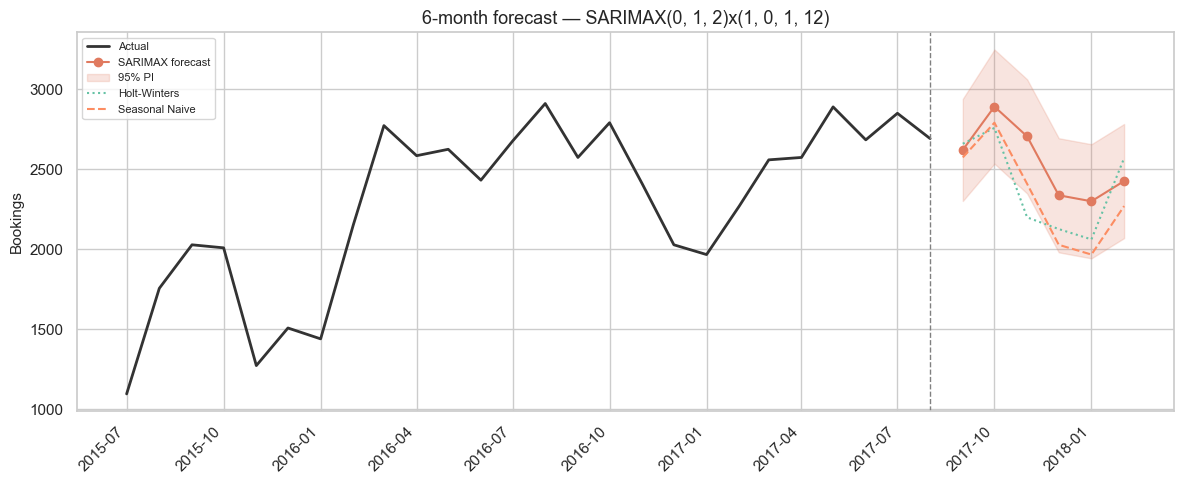

In [11]:
HORIZON = 6

# Refit winners on full sample
sarimax_full = fit_sarimax(y, best_order, best_seasonal)
hw_full, hw_full_kind = fit_holt_winters(y, "full")
print(f"Full-sample exponential smoothing kind: {hw_full_kind}")

print("Full-sample SARIMAX summary:")
print(sarimax_full.summary())

# Full-sample diagnostics
full_resid_n = len(pd.Series(sarimax_full.resid).dropna())
full_lags = max(4, min(10, full_resid_n // 3))
try:
    fig = sarimax_full.plot_diagnostics(figsize=(12, 8), lags=full_lags)
    fig.suptitle("Full-sample SARIMAX diagnostics", y=1.02)
    savefig("06_sarimax_full_diagnostics.png")
    plt.show()
except ValueError as e:
    print("Full-sample plot_diagnostics skipped:", e)


fc_obj = sarimax_full.get_forecast(steps=HORIZON)
fc_mean = fc_obj.predicted_mean.clip(lower=0)
fc_ci = fc_obj.conf_int(alpha=0.05)
fc_ci.columns = ["lower_95", "upper_95"]
fc_ci["lower_95"] = fc_ci["lower_95"].clip(lower=0)

fc_hw = pd.Series(hw_full.forecast(HORIZON), index=fc_mean.index).clip(lower=0)
fc_naive = pd.Series(seasonal_naive(y, HORIZON), index=fc_mean.index)

# Unified column name for HW family in forecast table
forecast_df = pd.DataFrame(
    {
        "ym": fc_mean.index,
        "sarimax": fc_mean.values,
        "sarimax_lower95": fc_ci["lower_95"].values,
        "sarimax_upper95": fc_ci["upper_95"].values,
        "holt_winters": fc_hw.values,
        "holt_kind_full": hw_full_kind,
        "seasonal_naive": fc_naive.values,
        "best_holdout_model": best_model,
        "sarimax_order": str(best_order),
        "sarimax_seasonal_order": str(best_seasonal),
    }
)
display(forecast_df.round(1))
forecast_df.to_csv(FIG_DIR / "forecast_next_6m.csv", index=False)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y.index, y.values, color="#333", lw=2, label="Actual")
ax.plot(forecast_df["ym"], forecast_df["sarimax"], marker="o", color="#e07a5f", label="SARIMAX forecast")
ax.fill_between(
    forecast_df["ym"],
    forecast_df["sarimax_lower95"],
    forecast_df["sarimax_upper95"],
    color="#e07a5f",
    alpha=0.2,
    label="95% PI",
)
ax.plot(forecast_df["ym"], forecast_df["holt_winters"], ls=":", label="Holt-Winters")
ax.plot(forecast_df["ym"], forecast_df["seasonal_naive"], ls="--", label="Seasonal Naive")
ax.axvline(y.index.max(), color="gray", ls="--", lw=1)
ax.set_title(f"6-month forecast — SARIMAX{best_order}x{best_seasonal}")
ax.set_ylabel("Bookings")
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.tick_params(axis="x", rotation=45)
plt.setp(ax.get_xticklabels(), ha="right")
savefig("07_forecast_horizon.png")
plt.show()

## 8. Dynamic pricing stance

Ghép forecast (model thắng holdout) với seasonal index (mean tháng / grand mean trên train+history 2016 nếu đủ):
- `combined_pressure >= 1.15` → PROTECT  
- `combined_pressure <= 0.90` → STIMULATE  
- else → NEUTRAL  

,ym,forecast_model,forecast,season_index,demand_index,combined_pressure,pricing_stance
0,2017-09-01,seasonal_naive,2573.0,1.006,1.125,1.066,"NEUTRAL — hold BAR, tactical weekend premium"
1,2017-10-01,seasonal_naive,2790.0,1.049,1.220,1.135,"NEUTRAL — hold BAR, tactical weekend premium"
2,2017-11-01,seasonal_naive,2408.0,0.805,1.053,0.929,"NEUTRAL — hold BAR, tactical weekend premium"
3,2017-12-01,seasonal_naive,2027.0,0.773,0.887,0.830,STIMULATE — promo / early-bird / package
4,2018-01-01,seasonal_naive,1966.0,0.745,0.860,0.802,STIMULATE — promo / early-bird / package
5,2018-02-01,seasonal_naive,2269.0,0.967,0.992,0.980,"NEUTRAL — hold BAR, tactical weekend premium"


Saved: reports\figures\18\08_pricing_stance.png


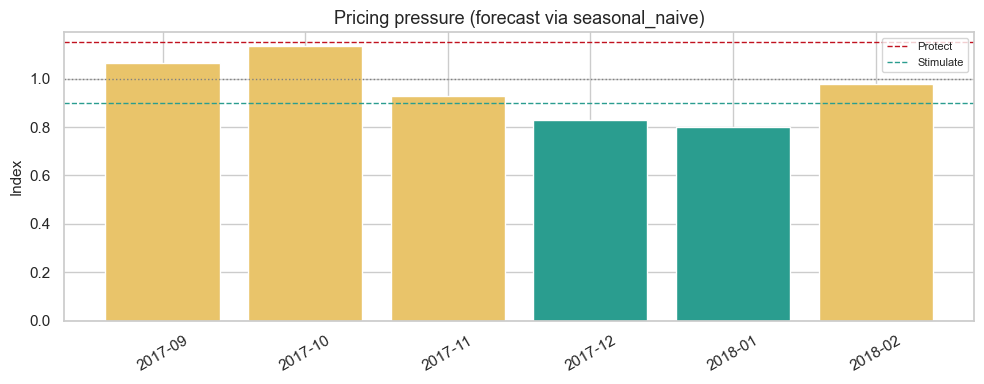

In [12]:
# Seasonal index from full history monthly means
month_mean = y.groupby(y.index.month).mean()
season_index = (month_mean / month_mean.mean()).rename("season_index")

# Choose forecast column for stance
if best_model == "seasonal_naive":
    fc_col = "seasonal_naive"
elif best_model == "sarimax":
    fc_col = "sarimax"
else:
    # holt_trend / holt_winters_seasonal → use full-sample seasonal HW when available
    fc_col = "holt_winters"

grand = float(month_mean.mean())
pricing = forecast_df[["ym", fc_col]].copy()
pricing = pricing.rename(columns={fc_col: "forecast"})
pricing["month"] = pricing["ym"].dt.month
pricing["season_index"] = pricing["month"].map(season_index)
pricing["demand_index"] = pricing["forecast"] / grand
pricing["combined_pressure"] = 0.5 * pricing["season_index"] + 0.5 * pricing["demand_index"]


def stance(row) -> str:
    if row["combined_pressure"] >= 1.15:
        return "PROTECT — raise / harden BAR, limit promo"
    if row["combined_pressure"] <= 0.90:
        return "STIMULATE — promo / early-bird / package"
    return "NEUTRAL — hold BAR, tactical weekend premium"


pricing["pricing_stance"] = pricing.apply(stance, axis=1)
pricing["forecast_model"] = best_model
cols = [
    "ym", "forecast_model", "forecast", "season_index",
    "demand_index", "combined_pressure", "pricing_stance",
]
display(pricing[cols].round(3))
pricing[cols].to_csv(FIG_DIR / "pricing_stance_forecast.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 4))
colors = pricing["pricing_stance"].map(
    {
        "PROTECT — raise / harden BAR, limit promo": "#c1121f",
        "STIMULATE — promo / early-bird / package": "#2a9d8f",
        "NEUTRAL — hold BAR, tactical weekend premium": "#e9c46a",
    }
)
ax.bar(pricing["ym"].dt.strftime("%Y-%m"), pricing["combined_pressure"], color=colors)
ax.axhline(1.15, color="#c1121f", ls="--", lw=1, label="Protect")
ax.axhline(0.90, color="#2a9d8f", ls="--", lw=1, label="Stimulate")
ax.axhline(1.0, color="gray", ls=":", lw=1)
ax.set_title(f"Pricing pressure (forecast via {best_model})")
ax.set_ylabel("Index")
ax.tick_params(axis="x", rotation=30)
ax.legend(fontsize=8)
savefig("08_pricing_stance.png")
plt.show()

## 9. KPI summary & insights

In [13]:
mape_map = metrics_df.set_index("model")["MAPE"].to_dict()
insights = [
    f"- Skill: statsmodels Workflow 4 (ADF/KPSS → ACF/PACF → SARIMAX AIC grid → diagnostics → forecast CI).",
    f"- Series: {len(y)} months, {fmt_int(y.sum())} stay bookings; differencing chosen d={d_order}, D={D_order}.",
    f"- Best SARIMAX (train AIC): {best_order} x {best_seasonal} (AIC={best['aic']:.1f}, BIC={best['bic']:.1f}).",
    f"- Holdout MAPE: "
    + ", ".join(f"{k}={v:.1%}" for k, v in mape_map.items()),
    f"- Best holdout model: **{best_model}**.",
    f"- SARIMAX 95% PI holdout coverage: {inside:.1%}.",
    "- Chuỗi ngắn (~26 điểm) → ưu tiên holdout accuracy + residual diagnostics, không chỉ AIC.",
]

print("=" * 72)
print("DEMAND FORECASTING INSIGHTS (statsmodels)")
print("=" * 72)
for line in insights:
    print(line)

print("\nAction implications:")
for a in [
    "- Dùng forecast + pricing stance để set rate calendar tháng.",
    "- Nếu SARIMAX residuals còn autocorrelation (Ljung-Box p nhỏ): đơn giản hóa order hoặc tăng dữ liệu.",
    "- Khi có thêm năm: mở rộng grid / thêm exog (lead_time median, channel mix).",
    "- Liên kết notebook 17 (ADR season/weekend) với stance PROTECT/STIMULATE.",
]:
    print(a)

kpi = pd.DataFrame(
    [
        {"metric": "n_months", "value": len(y)},
        {"metric": "total_stay_bookings", "value": int(y.sum())},
        {"metric": "diff_d", "value": d_order},
        {"metric": "diff_D", "value": D_order},
        {"metric": "sarimax_order", "value": str(best_order)},
        {"metric": "sarimax_seasonal_order", "value": str(best_seasonal)},
        {"metric": "sarimax_aic_train", "value": round(float(best["aic"]), 2)},
        {"metric": "sarimax_bic_train", "value": round(float(best["bic"]), 2)},
        {"metric": "best_holdout_model", "value": best_model},
        {"metric": "best_holdout_mape", "value": round(float(metrics_df.iloc[0]["MAPE"]), 4)},
        {"metric": "naive_holdout_mape", "value": round(float(mape_map.get("seasonal_naive", np.nan)), 4)},
        {
            "metric": "hw_holdout_mape",
            "value": round(float(mape_map.get(hw_holdout_label, np.nan)), 4),
        },
        {"metric": "hw_holdout_kind", "value": hw_holdout_label},
        {"metric": "hw_full_kind", "value": hw_full_kind},
        {"metric": "sarimax_holdout_mape", "value": round(float(mape_map.get("sarimax", np.nan)), 4)},
        {"metric": "sarimax_pi95_coverage", "value": round(float(inside), 4)},
        {"metric": "forecast_horizon_months", "value": HORIZON},
        {"metric": "statsmodels_version", "value": sm.__version__},
    ]
)
display(kpi)
kpi.to_csv(FIG_DIR / "kpi_summary.csv", index=False)
print(f"Saved KPI: {(FIG_DIR / 'kpi_summary.csv').relative_to(ROOT)}")

DEMAND FORECASTING INSIGHTS (statsmodels)
- Skill: statsmodels Workflow 4 (ADF/KPSS → ACF/PACF → SARIMAX AIC grid → diagnostics → forecast CI).
- Series: 26 months, 59.527 stay bookings; differencing chosen d=1, D=0.
- Best SARIMAX (train AIC): (0, 1, 2) x (1, 0, 1, 12) (AIC=62.8, BIC=59.7).
- Holdout MAPE: seasonal_naive=6.9%, holt_trend=8.1%, sarimax=9.1%
- Best holdout model: **seasonal_naive**.
- SARIMAX 95% PI holdout coverage: 100.0%.
- Chuỗi ngắn (~26 điểm) → ưu tiên holdout accuracy + residual diagnostics, không chỉ AIC.

Action implications:
- Dùng forecast + pricing stance để set rate calendar tháng.
- Nếu SARIMAX residuals còn autocorrelation (Ljung-Box p nhỏ): đơn giản hóa order hoặc tăng dữ liệu.
- Khi có thêm năm: mở rộng grid / thêm exog (lead_time median, channel mix).
- Liên kết notebook 17 (ADR season/weekend) với stance PROTECT/STIMULATE.


,metric,value
0,n_months,26
1,total_stay_bookings,59527
2,diff_d,1
3,diff_D,0
4,sarimax_order,"(0, 1, 2)"
5,sarimax_seasonal_order,"(1, 0, 1, 12)"
6,sarimax_aic_train,62.81
7,sarimax_bic_train,59.74
8,best_holdout_model,seasonal_naive
9,best_holdout_mape,0.0693


Saved KPI: reports\figures\18\kpi_summary.csv
